   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4
(244, 7)


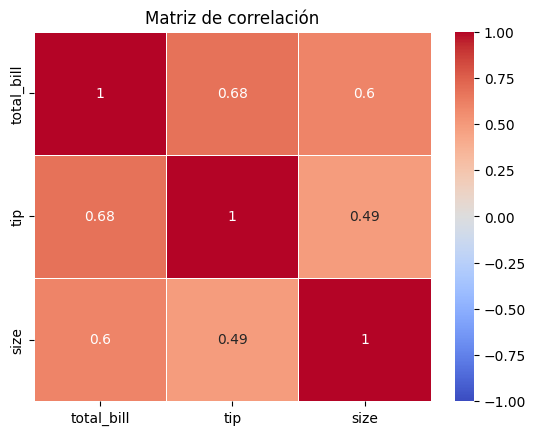

Coeficientes: [0.09088117 0.26501754]
Intercepto: 0.5681370921350046
R2: 0.4811084097989491
RMSE: 0.8053568271607013


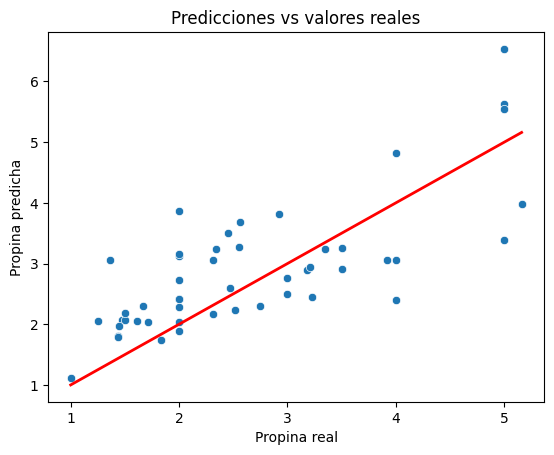

In [7]:
#Ejercicio de propinas de restaurante, con esto quiero predecir una propina usando total de la cuenta 
#  la cantidad de platos consumidos

## Primero voy a cargas las librerias para analisis de datos 

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

## Cargar el dataset 

data = sns.load_dataset("tips")

print(data.head())
print(data.shape) # este me muestra el tamaño del dataset

## Crear el matriz de correlacion para ver la relacion entre las variables
corr_matriz = data.corr(numeric_only=True)

sns.heatmap(corr_matriz,
            annot=True,
            cmap="coolwarm",
            linewidths=0.7,
            vmin=-1,
            vmax=1)

plt.title("Matriz de correlación")
plt.show()


## Variables numéricas en este dataset: total_bill - tip - size

## Con esto concluyo que con cuentas más altas + mayor propina y entre grupos más grandes + mayor propina

##Definir variables del modelo : Aquí se separan variables predictoras y variable objetivo.

#X → variables independientes
#Y → variable dependiente

x = data[["total_bill", "size"]]
y = data["tip"]

#tip = f(total_bill, size)
#Es decir, queremos predecir la propina usando el valor de la cuenta y el número de personas.

# Dividir los datos

#Se separa el dataset en datos de entrenamiento y de prueba.80 % Entrenamiento y 20% prueba para evaluar el modelo

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

# Crear el modelo de regresión lineal

model = LinearRegression()

#La ecuación general será:

#tip = b0 + b1(total_bill) + b2(size) donde: b0 → intercepto b1 y b2 = coeficientes

#Entrenar el modelo
model.fit(x_train, y_train)

#El modelo aprende la relación entre:


#Hacer predicciones:El modelo ahora intenta predecir la propina usando los datos de prueba.

y_predic = model.predict(x_test)

#Evaluar el modelo Se calculan dos métricas.

r2 = r2_score(y_test, y_predic)
rmse = mean_squared_error(y_test, y_predic)**(1/2)

print("Coeficientes:", model.coef_)
print("Intercepto:", model.intercept_)
print("R2:", r2)
print("RMSE:", rmse)

##Interpretación:

#R² Indica qué tan bien explica el modelo los datos. Significa que el modelo explica 50% de la variación de las propinas.

#RMSE Mide el error promedio del modelo.

#Mientras más bajo sea el RMSE, mejor el modelo.

#Gráfico de predicciones
sns.scatterplot(x=y_test, y=y_predic)

line = [y_test.min(), y_test.max()]
plt.plot(line, line, color="red", linewidth=2)

plt.title("Predicciones vs valores reales")
plt.xlabel("Propina real")
plt.ylabel("Propina predicha")
plt.show()

#Interpretación:
#cada punto es una predicción
#la línea roja representa predicción perfecta
#Si los puntos están cerca de la línea = modelo bueno.

#Conclusión del análisis


#el total de la cuenta tiene la mayor influencia en la propina, los grupos más grandes tienden a dejar más propina 
# la regresión lineal permite estimar la propina esperada con un error moderado
